# Exploit-search GD restart trajectories (M5)

Isolates and visualizes the multistart gradient-descent behavior inside
`anytimeacquisition.search.exploit.exploit_search` (M5's exploit branch —
see `docs/ROADMAP.md` Phase 5 / `docs/milestones/M5.md`): a few steps of
projected GD, run from several restarts (one seeded at the current
incumbent, the rest random), directly on a `BNNPrior` instance's own known,
differentiable surface (`evaluate(..., noise=False)`).

Two independent 2D BNN instances (`BNNPrior(batch_size=2, x_dim=2, ...)`),
one random context each, `exploit_search(..., record_trajectory=True)`
recording every restart's position at every GD step. Plotted with
`plot_restart_trajectories` (also in `search/exploit.py`) over the
instance's own true surface, decoded as a dense-grid heatmap.

Worth watching for: whether the restarts on a given instance converge to
one basin or spread across several distinct local optima — this is exactly
the question behind the "multi-basin exploitation-pull fix" flagged as not
yet implemented in `docs/milestones/M5.md` (right now `exploit_search`
returns only the single best restart, discarding the rest).

In [1]:
import torch

from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.search.exploit import exploit_search, plot_restart_trajectories

torch.manual_seed(0)

## Two 2D BNN instances, one random context each

`batch_size=2` gives two independently drawn architectures/weights (each
`BNNPrior` batch element is its own random-depth/-width tanh MLP, see M1) —
"two BNN instances" in the vectorized sense this repo uses throughout.

In [2]:
x_dim = 2
prior = BNNPrior(batch_size=2, x_dim=x_dim, seed=3)
prior.reset()

x_context, y_context, _, _ = prior.sample_episode(n_train=6, n_test=0)
incumbent = y_context.min(dim=1).values
print("depths:", prior.depth.tolist())
print("widths:", prior.width.tolist())
print("random context incumbent y per instance (lower is better):", incumbent.tolist())

depths: [25, 25]
widths: [64, 121]
random context incumbent y per instance (lower is better): [0.39604195952415466, 0.08618256449699402]


## Run `exploit_search` with trajectory recording

A few GD steps (`n_steps=40`), several restarts (`n_restarts=10`) per
instance — `record_trajectory=True` returns every restart's position after
each projected-GD step, `[n_steps+1, B, n_restarts, x_dim]`, in addition to
the usual `(x_star, y_star)`.

In [3]:
x_star, y_star, trajectory = exploit_search(
    prior, x_context, y_context, n_restarts=10, n_steps=40, lr=0.05, record_trajectory=True,
)
print("trajectory shape [n_steps+1, B, n_restarts, x_dim]:", tuple(trajectory.shape))
print("y* found per instance:                              ", y_star.tolist())
print("vs. context incumbent per instance:                  ", incumbent.tolist())
assert (y_star <= incumbent + 1e-4).all(), "exploit_search must never do worse than the known incumbent"


trajectory shape [n_steps+1, B, n_restarts, x_dim]: (41, 2, 10, 2)
y* found per instance:                               [0.36639106273651123, 0.07495694607496262]
vs. context incumbent per instance:                   [0.39604195952415466, 0.08618256449699402]


## Plot: true surface + restart trajectories, per instance

Filled contour = instance's true surface (dense grid, noise-free). ○ marks
each restart's starting point (one is always the current incumbent), line =
its GD path, ★ = where it ended up. □ = context points already observed.
Red ✕ = the `x_star` `exploit_search` actually returned (best restart, or a
fallback to the incumbent if no restart improved on it).

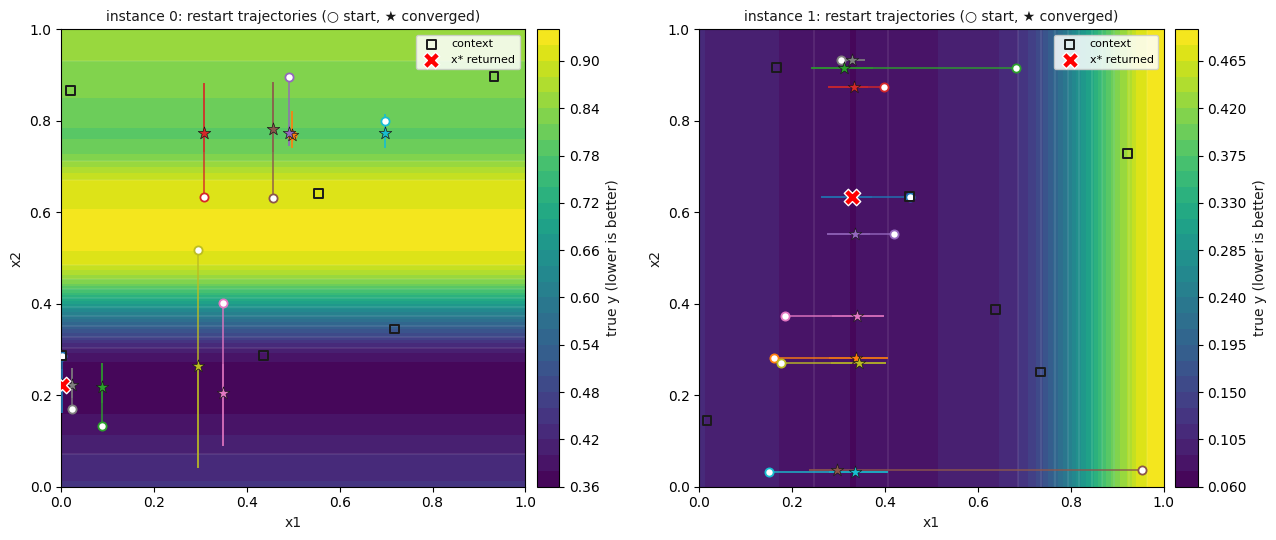

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for i, ax in enumerate(axes):
    plot_restart_trajectories(prior, x_context, y_context, trajectory, x_star, instance_idx=i, ax=ax)
fig.tight_layout()

## Does it also hold up across a full trajectory, at every incumbent change?

The single fixed context above is a start, but the real M5 use case is a
whole rollout: `exploit_search` gets called at *every* rollout step where
that instance's incumbent happened to improve
(`trainer/exit_rollout.py`'s `label_branches`, reusing the same
`incumbent_trajectory` from M3). Those improvement steps are not
synchronized across instances at all — they land at different rollout
steps, and a different *number* of times, per instance, since each
instance's own random-policy self-play trajectory is independent.

A fresh rollout on a new two-instance `BNNPrior` (own seed, so this is a
different pair of instances than the static demo above) makes that
concrete: instance 0 below improves 4 times (steps 0, 1, 5, 21), instance 1
only once (step 10) — different counts, different timing, exactly as
expected.

In [5]:
from anytimeacquisition.trainer.exit_rollout import (
    build_exploit_buffer,
    label_branches,
    plot_exploit_corrections_over_trajectory,
    random_policy,
    rollout_episode,
)

seed = 7
torch.manual_seed(seed)
prior_traj = BNNPrior(batch_size=2, x_dim=2, seed=seed)

n_init, n_steps = 5, 25
rollout = rollout_episode(prior_traj, n_init=n_init, n_steps=n_steps, policy_fn=random_policy)

is_exploit = label_branches(rollout["y_context"], n_init)
print(f"exploit-labeled steps per instance: {is_exploit.sum(dim=1).tolist()} / {n_steps}")
for b in range(prior_traj.B):
    step_idx = torch.nonzero(is_exploit[b], as_tuple=False).squeeze(-1).tolist()
    print(f"  instance {b}: incumbent improved at rollout steps {step_idx}")

exploit-labeled steps per instance: [4, 1] / 25
  instance 0: incumbent improved at rollout steps [0, 1, 5, 21]
  instance 1: incumbent improved at rollout steps [10]


### Run the exploit search at every one of those steps

`build_exploit_buffer` runs `exploit_search` once per exploit-labeled
rollout step (across the full batch, then keeps only the instances actually
labeled at that step — see its docstring for why it can't just slice the
prior down to a subset of instances) and returns a flat buffer tagging each
correction with which instance and which step it came from.

In [6]:
buffer = build_exploit_buffer(
    prior_traj, rollout, n_init, exploit_search_kwargs={"n_restarts": 10, "n_steps": 50},
)
print(f"buffer size: {len(buffer)} exploit-correction examples (matches the counts above)")

for ex in buffer:
    current_incumbent = ex.y_context.min().item()
    assert ex.y_star.item() <= current_incumbent + 1e-4, (
        f"instance {ex.instance_idx} step {ex.step}: oracle correction worse than its own current incumbent"
    )
print("every correction across the whole trajectory respects the never-worse-than-incumbent contract")

buffer size: 5 exploit-correction examples (matches the counts above)
every correction across the whole trajectory respects the never-worse-than-incumbent contract


### Plot: every correction found across the trajectory, per instance

Each ✕ is one exploit-branch correction, labeled by the rollout step it was
found at. Instance 0's four corrections (steps 0, 1, 5, 21) trace how the
oracle target moves as more context accumulates over the episode; instance
1 only ever gets one (step 10) — the "variable number of them" the question
was about, made visible.

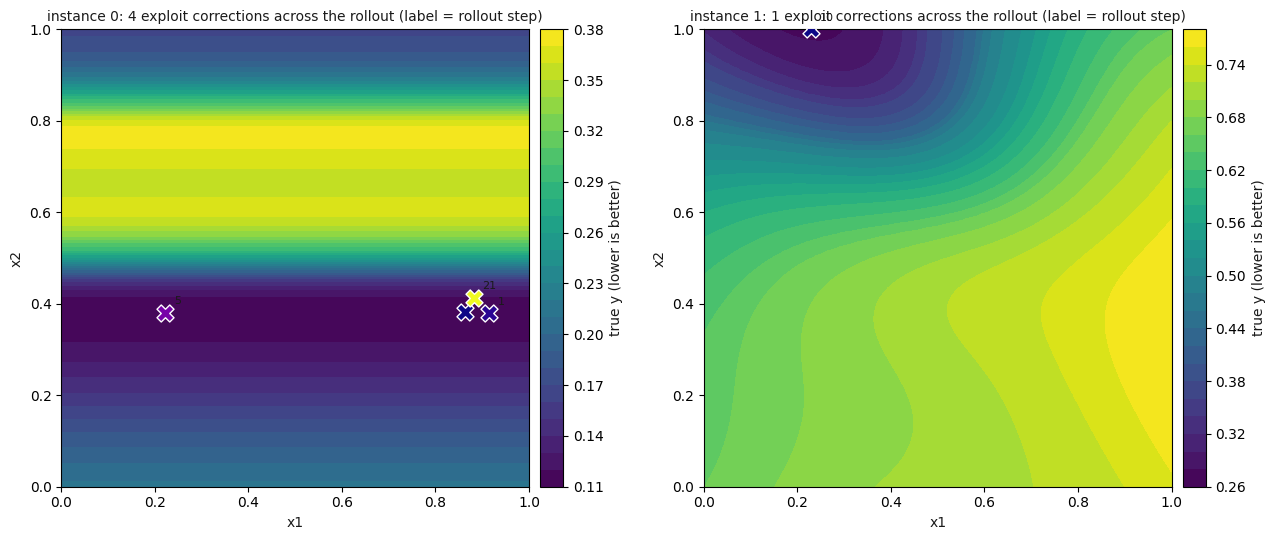

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for i, ax in enumerate(axes):
    plot_exploit_corrections_over_trajectory(prior_traj, buffer, instance_idx=i, ax=ax)
fig.tight_layout()